# Cube-in-farfield deformation

This tutorial builds a fluid volume mesh around a $20\,\mathrm{m}\times20\,\mathrm{m}\times20\,\mathrm{m}$ solid cube. Only the $+y$ half-domain is modeled: the plane $y=0$ is a symmetry boundary, the half-cube occupies $x,z\in[-10,10]$ and $y\in[0,10]$, and the farfield initially extends to $x,z=\pm100\,\mathrm{m}$ and $y=100\,\mathrm{m}$.

We stretch the cube surface by a factor of two in $x$, rotate it by $10^\circ$ about $y$, allow the farfield to move with the surrounding volume mesh, and verify the reverse derivative against a centered finite difference.

## 1. IDWarp-JAX overview

IDWarp-JAX propagates prescribed motion of boundary control surfaces into a volume mesh using inverse-distance-weighted interpolation. The deformation kernels run with JAX, and the API provides a reverse-mode derivative so sensitivities of volume coordinates can be propagated back to the surface coordinates and flow inputs.

The main workflow is:

1. Create a mesh dictionary containing volume points and boundary faces.
2. Call `build_volume_pts_func(mesh, base_volume_points, device)` once to prepare the fixed kd-tree routes.
3. Provide the desired absolute coordinates of every type-`1` control-surface point to `compute`.
4. Call `compute(surface_points, flow_condition)` to obtain deformed volume coordinates.
5. When derivatives are needed, call `compute_vjp(surface_points, flow_condition, volume_seed)` to propagate a volume cotangent back to the inputs.

With `return_aux=True`, the builder returns `compute, compute_vjp, aux`. The `aux["wall_points"]` array gives the reference control-surface coordinates, in the exact ordering expected by both functions, and `aux["wall_ids"]` maps them back to rows of the volume-point array. A `pitch` value in `flow_condition` applies a global rotation; this example keeps it at zero and rotates only the cube through its target surface coordinates.

## 2. Select precision and device

Change `DTYPE` and `DEVICE` here when running the notebook yourself.

In [1]:
import jax
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
import numpy as np

from cube_farfield_mesh import make_cube_farfield_mesh
from idwarp_jax.vol_warper import build_volume_pts_func

DTYPE = "f32"  # "f32" or "f64"
DEVICE = "cpu"  # "cpu" or "gpu"

jax.config.update("jax_enable_x64", DTYPE == "f64")
dtype = np.float64 if DTYPE == "f64" else np.float32
device = jax.devices(DEVICE)[0]
device

CpuDevice(id=0)

## 3. Build the exterior fluid mesh

The neighboring `cube_farfield_mesh.py` module creates the evenly spaced $20\times20\times20$ background grid and removes the eight cells inside the $+y$ half of the solid cube. It returns `mesh, extra`: `mesh` contains exactly the data required by `build_volume_pts_func`, while `extra` contains connectivity and dimensions used only for plotting.

The `mesh` dictionary contains:

- `mesh["points"]`: a NumPy array of volume-node coordinates with shape $(N_v,3)$. Each row is an $[x,y,z]$ coordinate, stored using the selected floating-point dtype.
- `mesh["faces"]["points"]`: a sequence of $N_f$ boundary faces. Each face contains integer indices into `mesh["points"]`. This tutorial has four vertices per face, so it is a NumPy array with shape $(N_f,4)$. For a general unstructured mesh with mixed face sizes, it can instead be a Python list of 1D integer arrays—for example, a three-index triangle followed by a four-index quadrilateral.
- `mesh["faces"]["type"]`: a NumPy integer array with shape $(N_f,)$. There is one classification per face: type `1` selects the moving cube surface, type `2` marks the symmetry plane, and type `3` identifies the passive farfield boundary.

Thus, unstructured connectivity is supported: faces do not need to follow a structured ordering, and different faces may contain different numbers of points. Every control-surface face must contain at least three points.

In [2]:
mesh, extra = make_cube_farfield_mesh(dtype=dtype)

print(
    "mesh['points']:",
    f"type={type(mesh['points']).__name__},",
    f"shape={mesh['points'].shape},",
    f"dtype={mesh['points'].dtype}",
)
print(
    "mesh['faces']['points']:",
    f"type={type(mesh['faces']['points']).__name__},",
    f"shape={mesh['faces']['points'].shape},",
    f"dtype={mesh['faces']['points'].dtype}",
)
print(
    "mesh['faces']['type']:",
    f"type={type(mesh['faces']['type']).__name__},",
    f"shape={mesh['faces']['type'].shape},",
    f"dtype={mesh['faces']['type'].dtype}",
)

mesh['points']: type=ndarray, shape=(9259, 3), dtype=float32
mesh['faces']['points']: type=ndarray, shape=(2416, 4), dtype=int32
mesh['faces']['type']: type=ndarray, shape=(2416,), dtype=int32


## 4. Prepare and deform the mesh

`build_volume_pts_func(mesh, base_volume_points, device, ...)` prepares the mesh warper and returns reusable `compute` and `compute_vjp` functions. Its main inputs are:

- `mesh`: the volume points and boundary faces described above. Face type `1` selects the moving control surface.
- `base_volume_points`: the undeformed volume coordinates with shape $(N_v,3)$. The kd-tree routes are built for these fixed reference points.
- `device`: the JAX CPU or GPU device on which deformation kernels run.

With `return_aux=True`, the builder also returns `aux["wall_points"]`, the reference coordinates of the type-`1` cube points with shape $(N_s,3)$, and `aux["wall_ids"]`, their indices in the volume mesh.

Because only the cube has face type `1`, `surface = aux["wall_points"].copy()` contains only cube coordinates and no Boolean mask is needed. The type-`3` farfield is not a prescribed control surface: its nodes remain ordinary volume points and are free to move according to the IDW deformation.

`compute(surface, flow)` takes the absolute target coordinates of the cube and a dictionary containing a scalar `pitch` in degrees. It returns the deformed volume coordinates with shape $(N_v,3)$. Here `pitch` stays zero because a nonzero value would rotate the entire domain.

In [3]:
compute, compute_vjp, aux = build_volume_pts_func(
    mesh,
    mesh["points"],
    device,
    return_aux=True,
    print_timings=True,
    progress=False,
    zeroCornerRotations=True,
)

surface = aux["wall_points"].copy()
surface[:, 0] *= 2.0

theta = np.deg2rad(dtype(10.0))
x_body = surface[:, 0].copy()
z_body = surface[:, 2].copy()
surface[:, 0] = np.cos(theta) * x_body + np.sin(theta) * z_body
surface[:, 2] = -np.sin(theta) * x_body + np.cos(theta) * z_body

flow = {"pitch": np.asarray(0.0, dtype=dtype)}
deformed = compute(surface, flow)
print(f"moving cube points: {len(surface):,}")

* evaluated volume deformation (9259 pts) (0.252 sec)
moving cube points: 25


## 5. Check the reverse derivative

`compute_vjp(surface_points, flow_condition, volume_seed)` evaluates a vector-Jacobian product without forming the full Jacobian. The first two inputs match `compute`; `volume_seed` is a cotangent with the same $(N_v,3)$ shape as the deformed-volume output. It returns `d_surface` with shape $(N_s,3)$ and `d_flow`, a dictionary containing the scalar derivative with respect to `pitch`.

For a cube-surface direction $p$ and volume seed $w$, we compare

$$w^T Jp \quad\text{with}\quad (J^T w)^T p.$$

The left side uses a centered finite difference, while the right side contracts `d_surface` from the production VJP with the chosen cube-surface direction.

In [4]:
rng = np.random.default_rng(7)
direction = rng.normal(scale=0.1, size=surface.shape).astype(dtype)
direction[np.isclose(surface[:, 1], 0.0), 1] = 0.0
seed = rng.normal(size=deformed.shape).astype(dtype)
seed /= np.linalg.norm(seed)
step = dtype(1.0e-1 if DTYPE == "f32" else 1.0e-5)

plus = compute(surface + step * direction, flow)
minus = compute(surface - step * direction, flow)
finite_difference = (plus - minus) / (2.0 * step)

d_surface, _ = compute_vjp(surface, flow, seed)
forward = np.vdot(seed, finite_difference)
reverse = np.vdot(d_surface, direction)
relative_error = abs(forward - reverse) / max(abs(forward), abs(reverse))
print(f"relative derivative error: {relative_error:.3e}")

* evaluated volume deformation (9259 pts) (0.015 sec)
* evaluated volume deformation (9259 pts) (0.010 sec)
* evaluated VJP volume deformation (9259 pts) (4.678 sec)
relative derivative error: 3.140e-04


## 6. Plot the 2D and 3D meshes

The first row shows the complete $y=0$ cross-section out to the original $\pm100\,\mathrm{m}$ farfield. The second row zooms in on the drilled-out cube, and the third row shows the full three-dimensional half-domain. The shaded region is the solid; all mesh cells lie outside it.

The 3D mesh opacity is controlled by `alpha` in `Line3DCollection`: `alpha=0` is fully transparent and `alpha=1` is fully opaque. Increase it for darker mesh lines or decrease it for a lighter view.

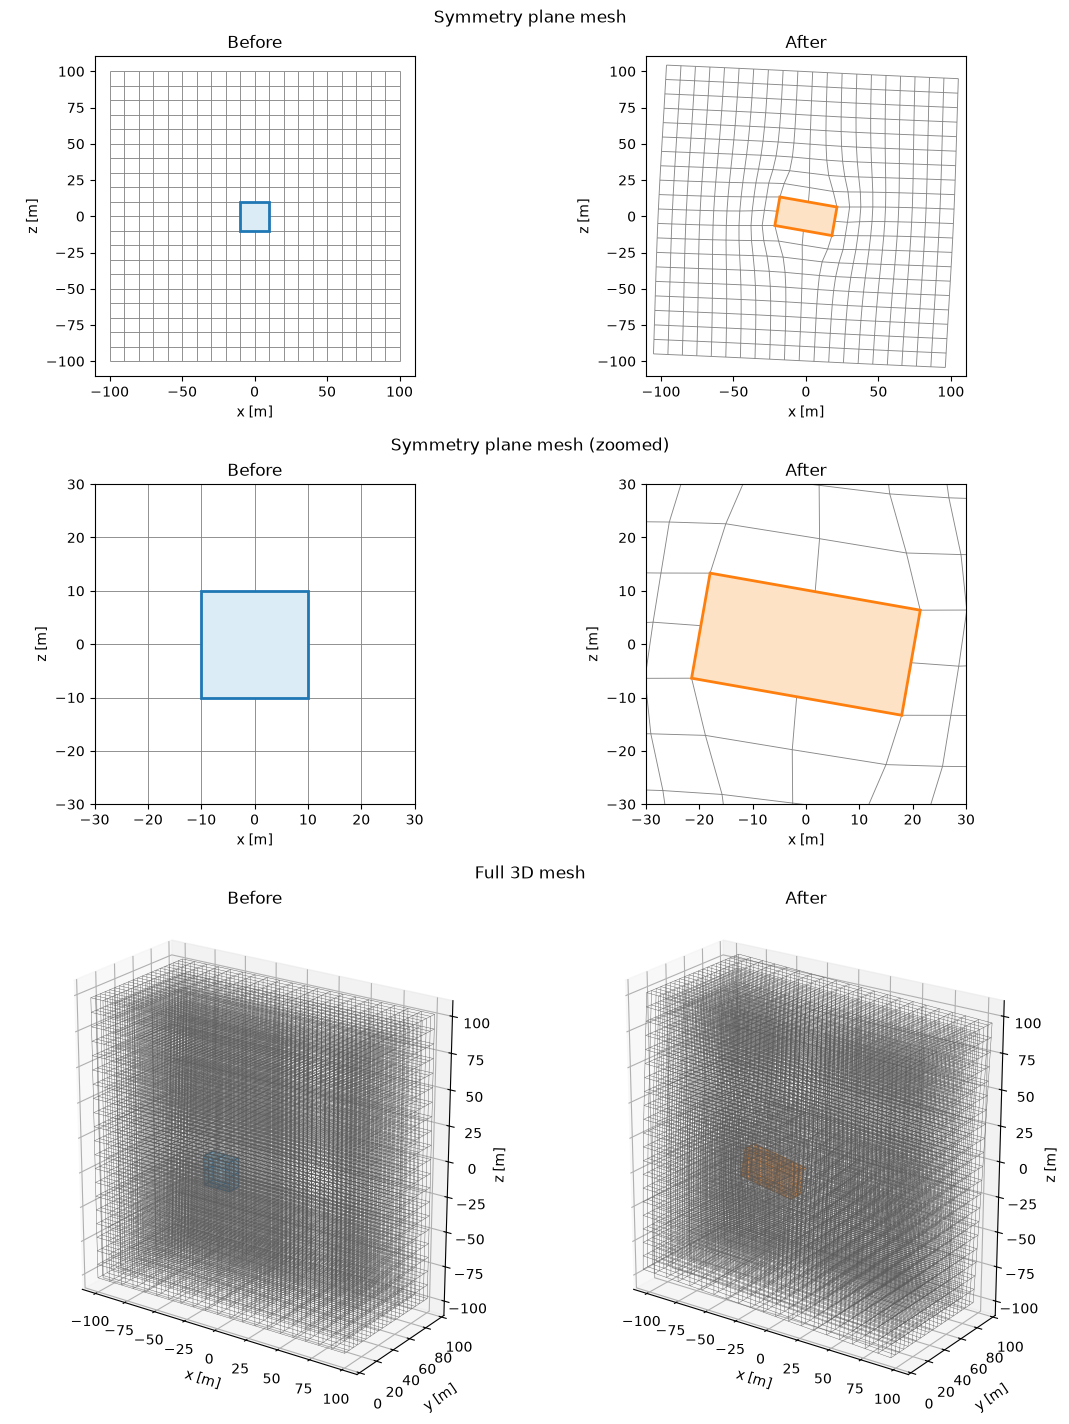

In [5]:
symmetry_faces = mesh["faces"]["points"][mesh["faces"]["type"] == 2]
plane_edges = np.concatenate((
    symmetry_faces[:, [0, 1]], symmetry_faces[:, [1, 2]],
    symmetry_faces[:, [2, 3]], symmetry_faces[:, [3, 0]],
))
plane_edges = np.unique(np.sort(plane_edges, axis=1), axis=0)

cell_edges = np.asarray([
    [0, 1], [1, 2], [2, 3], [3, 0],
    [4, 5], [5, 6], [6, 7], [7, 4],
    [0, 4], [1, 5], [2, 6], [3, 7],
])
volume_edges = extra["cell_points"][:, cell_edges].reshape(-1, 2)
volume_edges = np.unique(np.sort(volume_edges, axis=1), axis=0)

comparison_points = np.vstack((mesh["points"], deformed))
full_limit = 1.05 * np.max(np.abs(comparison_points[:, [0, 2]]))
plot_lower = comparison_points.min(axis=0)
plot_upper = comparison_points.max(axis=0)
plot_padding = 0.03 * np.maximum(plot_upper - plot_lower, 1.0)
plot_lower -= plot_padding
plot_upper += plot_padding


def body_polygon(is_deformed):
    half = extra["cube_half"]
    polygon = np.asarray([
        [-half, -half], [-half, half], [half, half],
        [half, -half], [-half, -half],
    ], dtype=dtype)
    if is_deformed:
        polygon[:, 0] *= 2.0
        x_coord = polygon[:, 0].copy()
        z_coord = polygon[:, 1].copy()
        polygon[:, 0] = np.cos(theta) * x_coord + np.sin(theta) * z_coord
        polygon[:, 1] = -np.sin(theta) * x_coord + np.cos(theta) * z_coord
    return polygon


def plot_cross_section(axis, points, is_deformed, limits, color):
    edge_points = points[plane_edges]
    segments = np.stack((edge_points[:, :, 0], edge_points[:, :, 2]), axis=-1)
    axis.add_collection(LineCollection(
        segments, colors="0.45", linewidths=0.65, alpha=0.85,
    ))
    polygon = body_polygon(is_deformed)
    fill_color = "#dcecf7" if color == "C0" else "#fde2c5"
    axis.fill(
        polygon[:, 0], polygon[:, 1],
        facecolor=fill_color, edgecolor=color, linewidth=2.0, zorder=3,
    )
    axis.set(xlim=limits, ylim=limits, xlabel="x [m]", ylabel="z [m]")
    axis.set_aspect("equal", adjustable="box")


def plot_full_3d(axis, points, color):
    mesh_segments = points[volume_edges]
    axis.add_collection3d(Line3DCollection(
        mesh_segments, colors="0.35", linewidths=0.30, alpha=1.00,
    ))
    fill_color = "#9ecae1" if color == "C0" else "#fdae6b"
    axis.add_collection3d(Poly3DCollection(
        points[extra["cube_faces"]], facecolors=fill_color,
        edgecolors=color, linewidths=0.8, alpha=1.0,
    ))
    axis.set(
        xlim=(plot_lower[0], plot_upper[0]),
        ylim=(plot_lower[1], plot_upper[1]),
        zlim=(plot_lower[2], plot_upper[2]),
        xlabel="x [m]", ylabel="y [m]", zlabel="z [m]",
    )
    axis.set_box_aspect(plot_upper - plot_lower)
    axis.view_init(elev=22, azim=-55)


figure = plt.figure(figsize=(11, 14), constrained_layout=True)
rows = figure.subfigures(3, 1, height_ratios=(1.0, 1.0, 1.3))

full_axes = rows[0].subplots(1, 2)
rows[0].suptitle("Symmetry plane mesh")
plot_cross_section(full_axes[0], mesh["points"], False, (-full_limit, full_limit), "C0")
plot_cross_section(full_axes[1], deformed, True, (-full_limit, full_limit), "C1")

zoom_axes = rows[1].subplots(1, 2)
rows[1].suptitle("Symmetry plane mesh (zoomed)")
plot_cross_section(zoom_axes[0], mesh["points"], False, (-30, 30), "C0")
plot_cross_section(zoom_axes[1], deformed, True, (-30, 30), "C1")

three_d_axes = (
    rows[2].add_subplot(1, 2, 1, projection="3d"),
    rows[2].add_subplot(1, 2, 2, projection="3d"),
)
rows[2].suptitle("Full 3D mesh")
plot_full_3d(three_d_axes[0], mesh["points"], "C0")
plot_full_3d(three_d_axes[1], deformed, "C1")

for left, right in (full_axes, zoom_axes, three_d_axes):
    left.set_title("Before")
    right.set_title("After")

plt.show()